# **DEEP LEARNING INTRODUCTION**
___

**MATERIALS**
1. [Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus](#1)
    - [Konsep MLP](#11)
    - [Studi Kasus](#12)
2. [Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus](#2)
    - [Konsep CNN](#21)
    - [Studi Kasus](#22)
3. [Penerapan Transfer Learning: Penjelasan dan Studi Kasus](#3)
    - [Konsep Transfer Learning](#31)
    - [Studi Kasus](#32)

---

**SOURCES**
1. Tensorflow Keras:
    - Ver. 2.12.0
    - Documentations: https://www.tensorflow.org/versions/r2.12/api_docs/python/tf
    - Github: https://github.com/tensorflow/tensorflow
2. Datasets
    - CIFAR10: https://www.cs.toronto.edu/~kriz/cifar.html
    - MNIST: https://www.tensorflow.org/datasets/catalog/mnist
    - Tiny ImageNet: https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds (as pretrained weight)

---

In [2]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # Ignore TensorFlow INFO and WARNING messages

import tensorflow as tf
from tensorflow.python.client import device_lib

SEED = 42
tf.keras.utils.set_random_seed(SEED) # Set tf global random seed
tf.config.experimental.enable_op_determinism()

# Check for GPU availability
gpus = tf.config.list_physical_devices("GPU")
print(f"GPU Available: {bool(gpus)}")

if gpus:
    # !nvidia-smi
    tf.config.set_visible_devices(gpus, 'GPU')
    usage_devices = [gpu.name for gpu in tf.config.list_logical_devices('GPU')]

    devices = device_lib.list_local_devices()
    print("\nUsage Devices:")
    for dev in devices:
        if dev.name in usage_devices and dev.device_type == "GPU":
            print("Device:", dev.name)
            print("Description:", dev.physical_device_desc)


GPU Available: True

Usage Devices:
Device: /device:GPU:0
Description: device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:d8:00.0, compute capability: 6.0


In [3]:
# Libraries and variables
import numpy as np
from matplotlib import pyplot as plt

import tensorflow_datasets as tfds
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.datasets import mnist, cifar10
import keras

# Create directories to store datasets and checkpoints
os.makedirs("/app/datasets", exist_ok=True)
os.makedirs("/app/checkpoints", exist_ok=True)

DATA_PATH = "/app/datasets"
CKPT_PATH = "/app/checkpoints"

In [4]:
# Generate plots for training results
def generate_plot(result):
    plt.figure(figsize=(12, 4))
    for idx, metric in enumerate(["Loss", "Accuracy"]):
        plt.subplot(1, 2, idx+1)
        plt.plot(result.history[metric.lower()], label=f'Training {metric}')
        plt.plot(result.history[f'val_{metric.lower()}'], label=f'Validation {metric}')
        plt.xlabel('Epoch')
        plt.ylabel(f'{metric}')
        plt.legend()
        plt.title(f'{metric} Over Time')
    plt.show()

In [5]:

def plot_predictions(model, X_vis_norm, X_vis_raw, y_true, img_shape, cmap="gray", title="Predictions vs True Labels"):
    scores = model.predict(X_vis_norm, verbose=0)
    predictions = tf.argmax(scores, axis=1).numpy()

    n = len(X_vis_norm)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 4))
    if n == 1:
        axes = [axes]

    for i in range(n):
        axes[i].imshow(X_vis_raw[i].reshape(img_shape), cmap=cmap)
        axes[i].set_title(
            f"Conf: {scores[i][predictions[i]]*100:.2f}%\n"
            f"Pred: {predictions[i]}\n"
            f"True: {y_true[i]}"
        )
        axes[i].axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


<a id="1"></a>
## **1. Penerapan Multilayer Perceptron (MLP): Penjelasan dan Studi Kasus**
---

<a id=11></a>
### **1.1 Konsep MLP**

Multilayer Perceptron (MLP) adalah salah satu fundamental dari Deep Learning.
Sebagaimana namanya, MLP terdiri dari banyak layer neuron atau perceptron. MLP
biasanya memiliki tiga jenis layer: input layer, hidden layer, dan output layer.

__Struktur MLP__

1. __Input Layer:__ Layer ini terdiri dari neuron yang merepresentasikan setiap fitur dalam data. Misalnya, jika kamu memiliki data gambar 28x28 pixel, maka input layer akan memiliki 784 neuron.

2. __Hidden Layer:__ Hidden layer berisi sejumlah neuron yang memproses informasi dari input layer. MLP bisa memiliki lebih dari satu hidden layer, inilah yang membuatnya menjadi "Deep" Neural Network.

3. __Output Layer:__ Layer ini berisi neuron yang merepresentasikan kelas atau nilai output dari masalah kita.

Setiap neuron dalam MLP dihubungkan dengan semua neuron di layer sebelum dan
sesudahnya. Bobot dan bias dikaitkan dengan setiap koneksi ini, dan ini yang diadjust
selama proses training.

__Fungsi Aktivasi dalam MLP__

MLP biasanya menggunakan fungsi aktivasi non-linear di neuronnya. Ini memungkinkan
MLP untuk memodelkan hubungan kompleks dan non-linear antara fitur. Fungsi aktivasi
yang paling umum digunakan adalah ReLU, tetapi yang lain seperti sigmoid atau tanh juga
dapat digunakan.

__Proses Training MLP__

MLP dilatih menggunakan metode yang disebut backpropagation dan algoritma optimasi
seperti Stochastic Gradient Descent (SGD) atau Adam. Proses training mencakup forward
pass di mana menghasilkan prediksi, lalu menghitung loss berdasarkan input saat ini, backward pass di mana menghitung gradient loss pakai backpropagation, dan optimasi di mana bobot dan bias diperbarui berdasarkan gradient yang dihasilkan.

<a id=12></a>
### **1.2 Studi Kasus**
Misalnya, kita ingin membuat MLP menggunakan library keras dari TensorFlow untuk mengklasifikasi objek dan digit. Berikut adalah kode yang kita perlukan:

#### Dataset 1 (MNIST)

In [4]:

def visualize_data(x, y, title, n=6):
    idx = np.random.choice(len(x), n, replace=False)

    plt.figure(figsize=(10,4))
    for i, j in enumerate(idx):
        plt.subplot(2,6,i+1)
        plt.imshow(x[j], cmap="gray")
        plt.title(int(y[j]))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

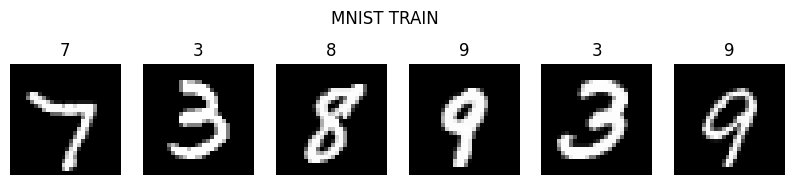

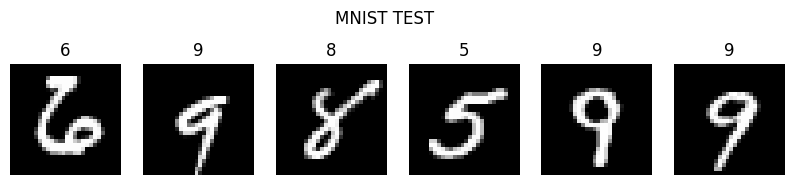

In [ ]:
# Load MNIST dataset
(X_train_MNIST, y_train_MNIST), (X_test_MNIST, y_test_MNIST) = mnist.load_data()



visualize_data(X_train_MNIST, y_train_MNIST, "MNIST TRAIN")
visualize_data(X_test_MNIST,  y_test_MNIST,  "MNIST TEST")


In [5]:
def class_distribution(y, name):
    y = y.reshape(-1)          # (N,1) -> (N,)
    y = y.astype(int)         # make sure it's integer labels

    counts = np.bincount(y, minlength=10)
    total = len(y)

    print(f"\n{name}")
    for i in range(10):
        print(f"Class {i}: {counts[i]:5d}  ({counts[i]/total:.3f})")
class_distribution(y_train_MNIST, "TRAIN")
class_distribution(y_test_MNIST,  "TEST")


TRAIN
Class 0:  5923  (0.099)
Class 1:  6742  (0.112)
Class 2:  5958  (0.099)
Class 3:  6131  (0.102)
Class 4:  5842  (0.097)
Class 5:  5421  (0.090)
Class 6:  5918  (0.099)
Class 7:  6265  (0.104)
Class 8:  5851  (0.098)
Class 9:  5949  (0.099)

TEST
Class 0:   980  (0.098)
Class 1:  1135  (0.114)
Class 2:  1032  (0.103)
Class 3:  1010  (0.101)
Class 4:   982  (0.098)
Class 5:   892  (0.089)
Class 6:   958  (0.096)
Class 7:  1028  (0.103)
Class 8:   974  (0.097)
Class 9:  1009  (0.101)


In [6]:
VAL_SIZE_MNIST=10000
BATCH_SIZE_MNIST = 64
RANDOM_SEED=67

perm = tf.random.shuffle(tf.range(len(X_train_MNIST)), seed=RANDOM_SEED)
X_train_MNIST = tf.gather(X_train_MNIST, perm)
y_train_MNIST = tf.gather(y_train_MNIST, perm)

X_val_MNIST = X_train_MNIST[-VAL_SIZE_MNIST:]
y_val_MNIST = y_train_MNIST[-VAL_SIZE_MNIST:]

X_train_MNIST = X_train_MNIST[:-VAL_SIZE_MNIST]
y_train_MNIST = y_train_MNIST[:-VAL_SIZE_MNIST]

print("Train:", X_train_MNIST.shape, y_train_MNIST.shape)
print("Val  :", X_val_MNIST.shape, y_val_MNIST.shape)
print("Test :", X_test_MNIST.shape, y_test_MNIST.shape)

Train: (50000, 28, 28) (50000,)
Val  : (10000, 28, 28) (10000,)
Test : (10000, 28, 28) (10000,)


In [7]:
def preprocess_ds_MNIST(x, y):
    x_new = tf.cast(x, tf.float32) / 255.0
    x_new = tf.reshape(x_new, [-1])
    y_new = tf.cast(y, tf.int32)
    print(f"Change shape from {x.shape} to {x_new.shape}")
    return x_new, y_new

train_ds_MNIST = tf.data.Dataset.from_tensor_slices((X_train_MNIST, y_train_MNIST))
train_ds_MNIST = train_ds_MNIST.shuffle(10000)
train_ds_MNIST = train_ds_MNIST.map(preprocess_ds_MNIST, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_MNIST = train_ds_MNIST.batch(BATCH_SIZE_MNIST)
train_ds_MNIST = train_ds_MNIST.prefetch(tf.data.AUTOTUNE)

val_ds_MNIST = tf.data.Dataset.from_tensor_slices((X_val_MNIST, y_val_MNIST))
val_ds_MNIST = val_ds_MNIST.map(preprocess_ds_MNIST, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_MNIST = val_ds_MNIST.batch(BATCH_SIZE_MNIST)
val_ds_MNIST = val_ds_MNIST.prefetch(tf.data.AUTOTUNE)

test_ds_MNIST = tf.data.Dataset.from_tensor_slices((X_test_MNIST, y_test_MNIST))
test_ds_MNIST = test_ds_MNIST.map(preprocess_ds_MNIST, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_MNIST = test_ds_MNIST.batch(BATCH_SIZE_MNIST)


Change shape from (28, 28) to (784,)
Change shape from (28, 28) to (784,)
Change shape from (28, 28) to (784,)


In [8]:
# Create model
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
], name="mlp_digit_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "mlp_digit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 32)                4128      
                                                                 
 dense_2 (Dense)             (None, 10)                330       
                                                                 
Total params: 104938 (409.91 KB)
Trainable params: 104938 (409.91 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [9]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/mlp_digit_recognizer.h5', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_MNIST,
    epochs=30, 
    validation_data=val_ds_MNIST, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/30
778/782 [============================>.] - ETA: 0s - loss: 0.3238 - accuracy: 0.9052
Epoch 1: val_loss improved from inf to 0.16876, saving model to /app/checkpoints/mlp_digit_recognizer.h5
782/782 [==============================] - 8s 8ms/step - loss: 0.3233 - accuracy: 0.9054 - val_loss: 0.1688 - val_accuracy: 0.9522
Epoch 2/30
  9/782 [..............................] - ETA: 4s - loss: 0.1673 - accuracy: 0.9549 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


782/782 [==============================] - ETA: 0s - loss: 0.1391 - accuracy: 0.9593
Epoch 2: val_loss improved from 0.16876 to 0.14314, saving model to /app/checkpoints/mlp_digit_recognizer.h5
782/782 [==============================] - 6s 7ms/step - loss: 0.1391 - accuracy: 0.9593 - val_loss: 0.1431 - val_accuracy: 0.9576
Epoch 3/30
782/782 [==============================] - ETA: 0s - loss: 0.0965 - accuracy: 0.9703
Epoch 3: val_loss improved from 0.14314 to 0.10967, saving model to /app/checkpoints/mlp_digit_recognizer.h5
782/782 [==============================] - 6s 8ms/step - loss: 0.0965 - accuracy: 0.9703 - val_loss: 0.1097 - val_accuracy: 0.9678
Epoch 4/30
782/782 [==============================] - ETA: 0s - loss: 0.0740 - accuracy: 0.9772
Epoch 4: val_loss improved from 0.10967 to 0.09563, saving model to /app/checkpoints/mlp_digit_recognizer.h5
782/782 [==============================] - 6s 7ms/step - loss: 0.0740 - accuracy: 0.9772 - val_loss: 0.0956 - val_accuracy: 0.9702
Epo

In [10]:
test_loss, test_acc = model.evaluate(test_ds_MNIST)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


157/157 [==============================] - 1s 3ms/step - loss: 0.1079 - accuracy: 0.9747
Test Accuracy: 97.47%


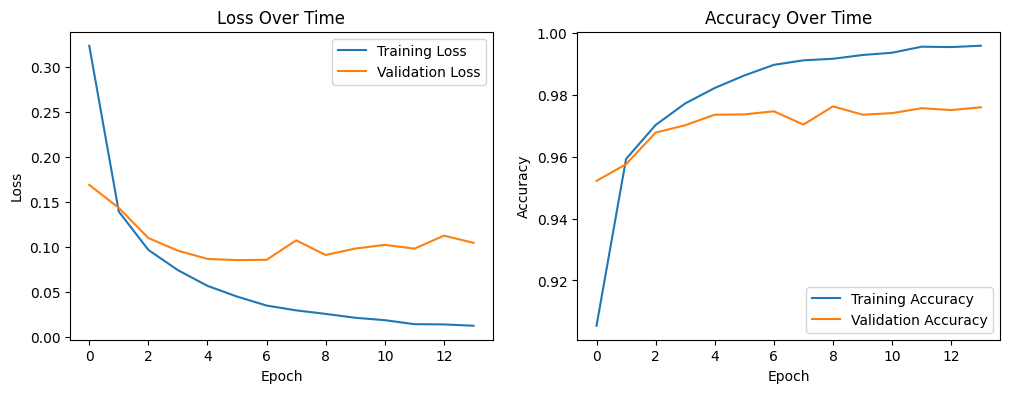

In [11]:
generate_plot(result)

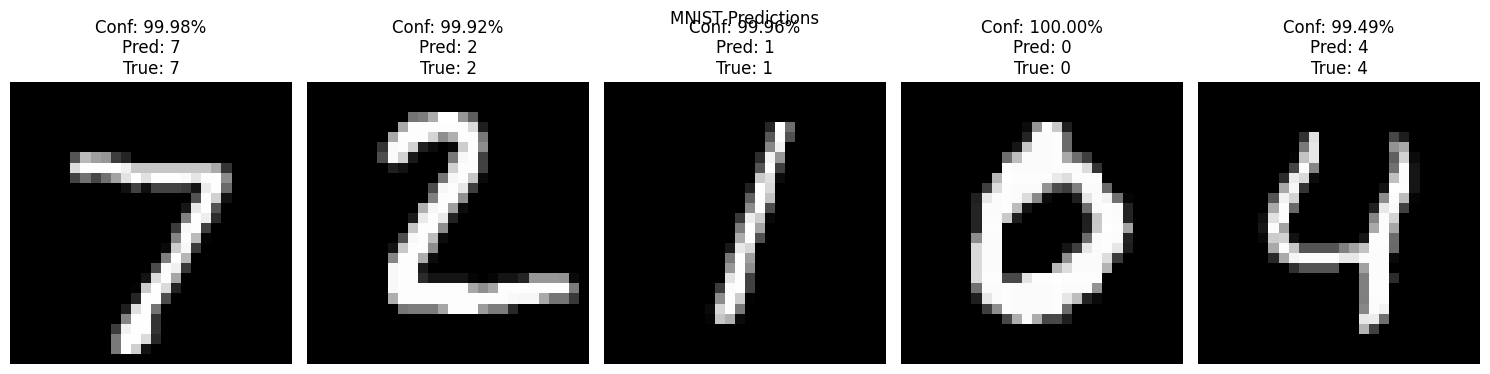

In [ ]:
# Load best weights
model=tf.keras.models.load_model(f"{CKPT_PATH}/mlp_digit_recognizer.h5")

# Take 5 samples
X_vis = X_test_MNIST[:5]
y_true = y_test_MNIST[:5]

# Preprocess EXACTLY like training
X_vis_norm = tf.cast(X_vis, tf.float32) / 255.0
X_vis_norm = tf.reshape(X_vis_norm, [5, -1])

plot_predictions(
    model,
    X_vis_norm,
    X_vis,
    y_true,
    img_shape=(28,28),
    title="MNIST Predictions"
)

#### Dataset 2 (CIFAR10)

/tmp/ipykernel_294649/244249850.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(int(y[j]))


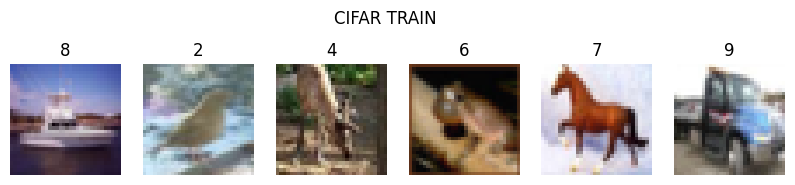

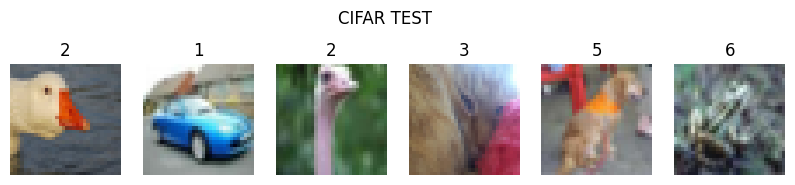

In [13]:
# Load Cifar10 dataset
(X_train_CIFAR, y_train_CIFAR), (X_test_CIFAR, y_test_CIFAR) = cifar10.load_data()

CIFAR_CLASS = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

visualize_data(X_train_CIFAR, y_train_CIFAR, "CIFAR TRAIN")
visualize_data(X_test_CIFAR,  y_test_CIFAR,  "CIFAR TEST")


In [14]:
class_distribution(y_train_CIFAR, "TRAIN")
class_distribution(y_test_CIFAR,  "TEST")


TRAIN
Class 0:  5000  (0.100)
Class 1:  5000  (0.100)
Class 2:  5000  (0.100)
Class 3:  5000  (0.100)
Class 4:  5000  (0.100)
Class 5:  5000  (0.100)
Class 6:  5000  (0.100)
Class 7:  5000  (0.100)
Class 8:  5000  (0.100)
Class 9:  5000  (0.100)

TEST
Class 0:  1000  (0.100)
Class 1:  1000  (0.100)
Class 2:  1000  (0.100)
Class 3:  1000  (0.100)
Class 4:  1000  (0.100)
Class 5:  1000  (0.100)
Class 6:  1000  (0.100)
Class 7:  1000  (0.100)
Class 8:  1000  (0.100)
Class 9:  1000  (0.100)


In [15]:
VAL_SIZE_CIFAR=10000
BATCH_SIZE_CIFAR=64
perm = tf.random.shuffle(tf.range(len(X_train_CIFAR)), seed=RANDOM_SEED)
X_train_CIFAR = tf.gather(X_train_CIFAR, perm)
y_train_CIFAR = tf.gather(y_train_CIFAR, perm)

X_val_CIFAR = X_train_CIFAR[-VAL_SIZE_CIFAR:]
y_val_CIFAR = y_train_CIFAR[-VAL_SIZE_CIFAR:]

X_train_CIFAR = X_train_CIFAR[:-VAL_SIZE_CIFAR]
y_train_CIFAR = y_train_CIFAR[:-VAL_SIZE_CIFAR]

print("Train:", X_train_CIFAR.shape, y_train_CIFAR.shape)
print("Val  :", X_val_CIFAR.shape, y_val_CIFAR.shape)
print("Test :", X_test_CIFAR.shape, y_test_CIFAR.shape)

Train: (40000, 32, 32, 3) (40000, 1)
Val  : (10000, 32, 32, 3) (10000, 1)
Test : (10000, 32, 32, 3) (10000, 1)


In [16]:
def preprocess_ds_CIFAR(x, y):
    x_new = tf.cast(x, tf.float32) / 255.0
    y_new = tf.cast(y, tf.int32)
    print(f"Change shape from {x.shape} to {x_new.shape}")
    return x_new, y_new

train_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_train_CIFAR, y_train_CIFAR))
train_ds_CIFAR = train_ds_CIFAR.shuffle(10000)
train_ds_CIFAR = train_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_CIFAR = train_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

val_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_val_CIFAR, y_val_CIFAR))
val_ds_CIFAR = val_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_CIFAR = val_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
val_ds_CIFAR = val_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

test_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_test_CIFAR, y_test_CIFAR))
test_ds_CIFAR = test_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_CIFAR = test_ds_CIFAR.batch(BATCH_SIZE_CIFAR)


Change shape from (32, 32, 3) to (32, 32, 3)
Change shape from (32, 32, 3) to (32, 32, 3)
Change shape from (32, 32, 3) to (32, 32, 3)


In [17]:
# Create model
model = keras.Sequential([
    keras.layers.Input(shape=(32,32,3)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(10, activation='softmax'),
], name="mlp_object_classifier")
initial_weights = model.get_weights()
model.summary()


Model: "mlp_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 3072)              0         
                                                                 
 dense_3 (Dense)             (None, 128)               393344    
                                                                 
 dense_4 (Dense)             (None, 32)                4128      
                                                                 
 dense_5 (Dense)             (None, 10)                330       
                                                                 
Total params: 397802 (1.52 MB)
Trainable params: 397802 (1.52 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)
# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/mlp_object_recognizer.h5', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_CIFAR,
    epochs=30, 
    validation_data=val_ds_CIFAR, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/30
620/625 [============================>.] - ETA: 0s - loss: 1.9645 - accuracy: 0.2856
Epoch 1: val_loss improved from inf to 1.85809, saving model to /app/checkpoints/mlp_object_recognizer.h5
625/625 [==============================] - 6s 8ms/step - loss: 1.9638 - accuracy: 0.2861 - val_loss: 1.8581 - val_accuracy: 0.3209
Epoch 2/30
621/625 [============================>.] - ETA: 0s - loss: 1.8139 - accuracy: 0.3454
Epoch 2: val_loss improved from 1.85809 to 1.80596, saving model to /app/checkpoints/mlp_object_recognizer.h5
625/625 [==============================] - 5s 7ms/step - loss: 1.8131 - accuracy: 0.3458 - val_loss: 1.8060 - val_accuracy: 0.3427
Epoch 3/30
624/625 [============================>.] - ETA: 0s - loss: 1.7341 - accuracy: 0.3771
Epoch 3: val_loss improved from 1.80596 to 1.72981, saving model to /app/checkpoints/mlp_object_recognizer.h5
625/625 [==============================] - 5s 8ms/step - loss: 1.7339 - accuracy: 0.3770 - val_loss: 1.7298 - val_accuracy: 

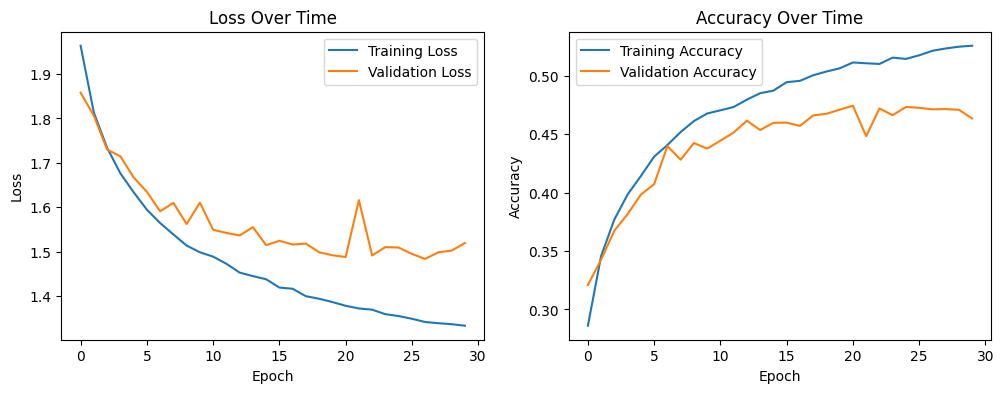

In [19]:
# Plot training history
generate_plot(result)

In [20]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/mlp_object_recognizer.h5')
test_loss_CIFAR, test_acc_CIFAR = model.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")


  1/157 [..............................] - ETA: 9s - loss: 1.3792 - accuracy: 0.5312

157/157 [==============================] - 1s 4ms/step - loss: 1.4499 - accuracy: 0.4849
Test Accuracy: 48.49%


(5, 32, 32, 3)
(5, 1)


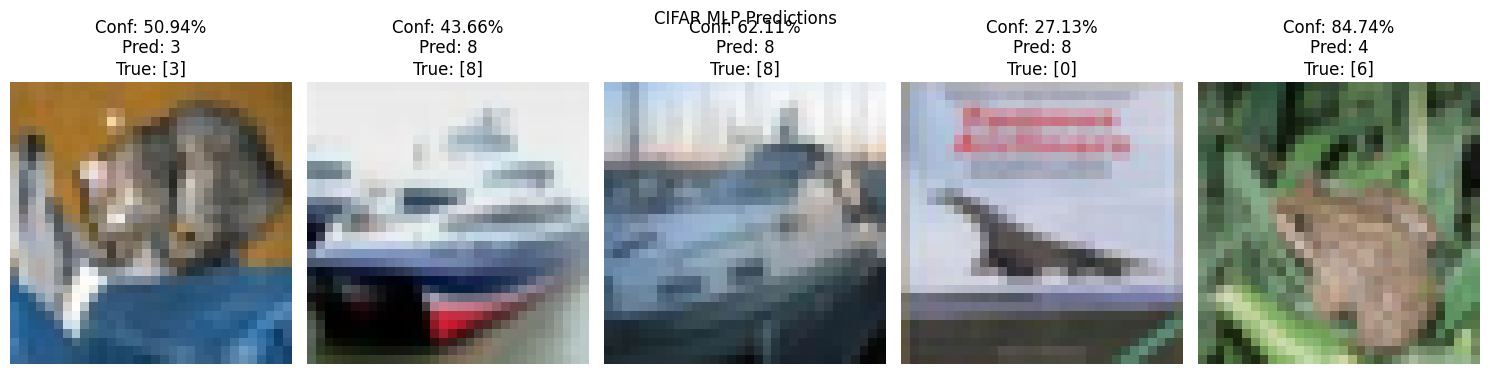

In [21]:
X_vis = X_test_CIFAR[:5]
y_true = y_test_CIFAR[:5]
print(X_vis.shape)
print(y_true.shape)
X_vis_norm = tf.cast(X_vis, tf.float32) / 255.0
# X_vis_norm = tf.reshape(X_vis_norm, [5, -1])

plot_predictions(
    model,
    X_vis_norm,
    X_vis,
    y_true,
    img_shape=(32,32,3),
    cmap=None,
    title="CIFAR MLP Predictions"
)


<a id="2"></a>
## **2. Penerapan Convolutional Neural Netowrk (CNN): Penjelasan dan Studi Kasus**
---

<a id=21></a>
### **2.1 Konsep CNN**

Convolutional Neural Network (CNN) adalah jenis khusus dari neural networks yang
dirancang khusus untuk memproses data dengan struktur grid seperti gambar. CNN telah
sukses besar dalam berbagai aplikasi pengenalan gambar dan video.

__Struktur CNN__
1. __Input Layer:__ Layer ini terdiri dari neuron yang merepresentasikan setiap input fitur dalam data. Umumnya berupa gambar berbentuk N (Total / Batch image), H (Height), W (Width), C (Channel).
2. __Convolutional Layer:__ Layer konvolusi adalah elemen inti dari CNN. Dalam layer ini, beberapa filter digunakan untuk melakukan operasi konvolusi pada input. Hasil dari operasi ini disebut feature map atau activation map.
3. __Pooling Layer:__ Pooling layer bertujuan untuk mengurangi dimensionalitas data. Ada berbagai teknik pooling, termasuk max pooling, average pooling, dan sum pooling.
4. __Fully Connected Layer:__ Fully connected layer menghubungkan setiap neuron di layer sebelumnya ke setiap neuron di layer berikutnya, mirip dengan apa yang kita lihat di MLP. Biasanya, fully connected layer ditempatkan di akhir arsitektur CNN, dan bertugas untuk menghasilkan prediksi akhir model.

__Fungsi Aktivasi dalam CNN__

ReLU (Rectified Linear Unit) adalah fungsi aktivasi yang paling sering digunakan dalam
CNN. Fungsi ini mampu mempercepat konvergensi jaringan neural dibandingkan dengan
sigmoid atau tanh.

__Proses Training CNN__

Proses pelatihan CNN serupa dengan MLP. Kami menggunakan metode seperti
backpropagation dan algoritma optimasi seperti Adam atau SGD untuk melatih model kami.
Kita menghitung loss dengan fungsi loss seperti cross-entropy, dan mengupdate
bobot dan bias berdasarkan gradien loss dari proses backward pass.

<a id=22></a>
### **2.2 Studi Kasus**
Alih-alih menggunakan MLP yang hanya memiliki layer sederhana, kita akan coba membuat model CNN pakai library keras dari TensorFlow untuk mengklasifikasi objek dan digit dengan hasil prediksi yang lebih baik. Berikut adalah kode yang kita perlukan:

#### Dataset 2 (MNIST)

In [6]:
# Load MNIST dataset
(train_ds_MNIST, test_ds_MNIST), info = tfds.load(
    "mnist",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)


In [7]:
VAL_SIZE_MNIST=10000
BATCH_SIZE_MNIST=64
RANDOM_SEED=67

train_ds_MNIST = train_ds_MNIST.shuffle(50_000, seed=RANDOM_SEED, reshuffle_each_iteration=False)

# Split
val_ds_MNIST   = train_ds_MNIST.take(VAL_SIZE_MNIST)
train_ds_MNIST = train_ds_MNIST.skip(VAL_SIZE_MNIST)

In [8]:
def preprocess_ds_MNIST(x, y):
    x_new = tf.cast(x, tf.float32) / 255.0
    y_new = tf.cast(y, tf.int32)
    print(f"Change shape from {x.shape} to {x_new.shape}")
    return x_new, y_new

# train_ds_MNIST = tf.data.Dataset.from_tensor_slices((X_train_MNIST, y_train_MNIST))
train_ds_MNIST = train_ds_MNIST.shuffle(10000)
train_ds_MNIST = train_ds_MNIST.map(preprocess_ds_MNIST, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_MNIST = train_ds_MNIST.batch(BATCH_SIZE_MNIST)
train_ds_MNIST = train_ds_MNIST.prefetch(tf.data.AUTOTUNE)

# val_ds_MNIST = tf.data.Dataset.from_tensor_slices((X_val_MNIST, y_val_MNIST))
val_ds_MNIST = val_ds_MNIST.map(preprocess_ds_MNIST, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_MNIST = val_ds_MNIST.batch(BATCH_SIZE_MNIST)
val_ds_MNIST = val_ds_MNIST.prefetch(tf.data.AUTOTUNE)

# test_ds_MNIST = tf.data.Dataset.from_tensor_slices((X_test_MNIST, y_test_MNIST))
test_ds_MNIST = test_ds_MNIST.map(preprocess_ds_MNIST, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_MNIST = test_ds_MNIST.batch(BATCH_SIZE_MNIST)


Change shape from (28, 28, 1) to (28, 28, 1)
Change shape from (28, 28, 1) to (28, 28, 1)
Change shape from (28, 28, 1) to (28, 28, 1)


In [9]:
# Create model

model = keras.Sequential([
    keras.Input(shape=(28,28,1)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_digit_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "cnn_digit_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 28, 28, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 14, 14, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                         

In [11]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [ ]:

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/cnn_digit_recognizer.h5', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_MNIST,
    epochs=50, 
    validation_data=val_ds_MNIST, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/50
782/782 [==============================] - ETA: 0s - loss: 0.1467 - accuracy: 0.9536
Epoch 1: val_loss improved from inf to 0.04539, saving model to /app/checkpoints/cnn_digit_recognizer.h5
782/782 [==============================] - 18s 16ms/step - loss: 0.1467 - accuracy: 0.9536 - val_loss: 0.0454 - val_accuracy: 0.9851
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


782/782 [==============================] - ETA: 0s - loss: 0.0417 - accuracy: 0.9871
Epoch 2: val_loss improved from 0.04539 to 0.03635, saving model to /app/checkpoints/cnn_digit_recognizer.h5
782/782 [==============================] - 12s 15ms/step - loss: 0.0417 - accuracy: 0.9871 - val_loss: 0.0363 - val_accuracy: 0.9897
Epoch 3/50
780/782 [============================>.] - ETA: 0s - loss: 0.0320 - accuracy: 0.9903
Epoch 3: val_loss did not improve from 0.03635
782/782 [==============================] - 12s 15ms/step - loss: 0.0320 - accuracy: 0.9903 - val_loss: 0.0512 - val_accuracy: 0.9844
Epoch 4/50
782/782 [==============================] - ETA: 0s - loss: 0.0253 - accuracy: 0.9921
Epoch 4: val_loss improved from 0.03635 to 0.02925, saving model to /app/checkpoints/cnn_digit_recognizer.h5
782/782 [==============================] - 12s 15ms/step - loss: 0.0253 - accuracy: 0.9921 - val_loss: 0.0293 - val_accuracy: 0.9910
Epoch 5/50
779/782 [============================>.] - ETA: 

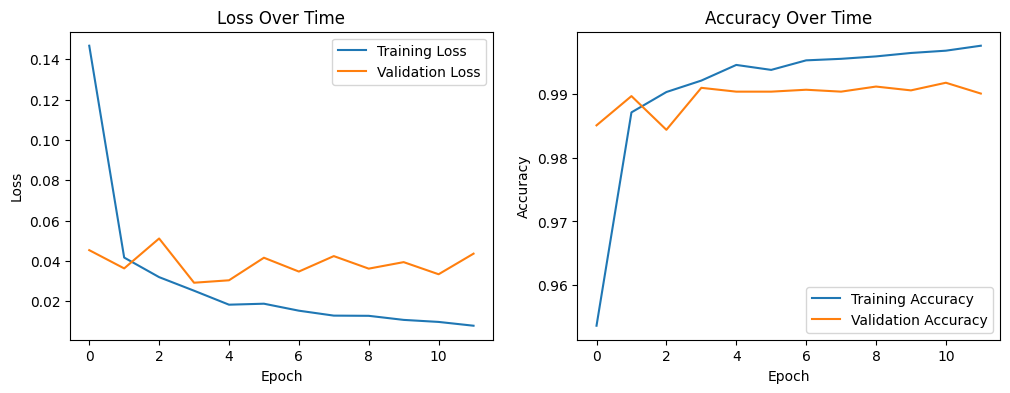

In [12]:

# Plot training history
generate_plot(result)

In [20]:
# Evaluate model
model=keras.models.load_model(f'{CKPT_PATH}/cnn_digit_recognizer.h5')
test_loss_MNIST, test_acc_MNIST = model.evaluate(test_ds_MNIST)
print(f"Test Accuracy: {test_acc_MNIST * 100:.2f}%")

157/157 [==============================] - 1s 4ms/step - loss: 0.0218 - accuracy: 0.9933
Test Accuracy: 99.33%


(5, 28, 28, 1)
(5, 1)


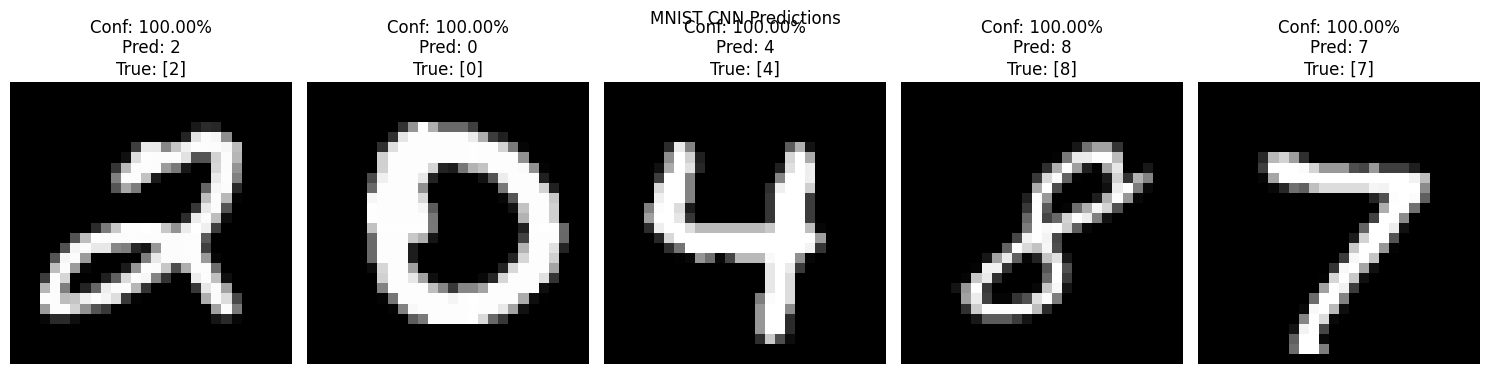

In [24]:
num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_MNIST.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32) * 255.0
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    model,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    img_shape=(28,28,1),
    title="MNIST CNN Predictions"
)


#### Dataset 1 (CIFAR10)

In [72]:
# Load Cifar10 dataset
(train_ds_CIFAR, test_ds_CIFAR), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)
CIFAR_CLASS = info.features["label"].names

In [73]:
VAL_SIZE_CIFAR=10000
BATCH_SIZE_CIFAR=64

train_ds_CIFAR = train_ds_CIFAR.shuffle(50_000, seed=RANDOM_SEED, reshuffle_each_iteration=False)

# Split
val_ds_CIFAR   = train_ds_CIFAR.take(VAL_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.skip(VAL_SIZE_CIFAR)

In [74]:
def preprocess_ds_CIFAR(x, y):
    x_new = tf.cast(x, tf.float32) / 255.0
    y_new = tf.cast(y, tf.int32)
    print(f"Change shape from {x.shape} to {x_new.shape}")
    return x_new, y_new

# train_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_train_CIFAR, y_train_CIFAR))
train_ds_CIFAR = train_ds_CIFAR.shuffle(10000)
train_ds_CIFAR = train_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
train_ds_CIFAR = train_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
train_ds_CIFAR = train_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

# val_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_val_CIFAR, y_val_CIFAR))
val_ds_CIFAR = val_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_CIFAR = val_ds_CIFAR.batch(BATCH_SIZE_CIFAR)
val_ds_CIFAR = val_ds_CIFAR.prefetch(tf.data.AUTOTUNE)

# test_ds_CIFAR = tf.data.Dataset.from_tensor_slices((X_test_CIFAR, y_test_CIFAR))
test_ds_CIFAR = test_ds_CIFAR.map(preprocess_ds_CIFAR, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_CIFAR = test_ds_CIFAR.batch(BATCH_SIZE_CIFAR)


Change shape from (32, 32, 3) to (32, 32, 3)
Change shape from (32, 32, 3) to (32, 32, 3)
Change shape from (32, 32, 3) to (32, 32, 3)


In [44]:
# Create model

model = keras.Sequential([
    keras.Input(shape=(32,32,3)),

    # Block 1
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 2
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Block 3
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.Conv2D(128, 3, padding="same", activation="relu"),
    keras.layers.MaxPool2D(2),
    # Classifier
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dense(10, activation="softmax")
], name="cnn_object_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "cnn_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_6 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 conv2d_7 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_9 (Conv2D)           (None, 16, 16, 64)        36928     
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                        

In [46]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer="adam", loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_recognizer.h5', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_CIFAR,
    epochs=50, 
    validation_data=val_ds_CIFAR, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/50
622/625 [============================>.] - ETA: 0s - loss: 1.6772 - accuracy: 0.3810
Epoch 1: val_loss improved from inf to 1.40885, saving model to /app/checkpoints/cnn_object_recognizer.h5
625/625 [==============================] - 14s 16ms/step - loss: 1.6761 - accuracy: 0.3817 - val_loss: 1.4088 - val_accuracy: 0.4821
Epoch 2/50


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


625/625 [==============================] - ETA: 0s - loss: 1.1716 - accuracy: 0.5807
Epoch 2: val_loss improved from 1.40885 to 1.04414, saving model to /app/checkpoints/cnn_object_recognizer.h5
625/625 [==============================] - 10s 16ms/step - loss: 1.1716 - accuracy: 0.5807 - val_loss: 1.0441 - val_accuracy: 0.6274
Epoch 3/50
623/625 [============================>.] - ETA: 0s - loss: 0.9175 - accuracy: 0.6784
Epoch 3: val_loss improved from 1.04414 to 0.89244, saving model to /app/checkpoints/cnn_object_recognizer.h5
625/625 [==============================] - 10s 16ms/step - loss: 0.9175 - accuracy: 0.6786 - val_loss: 0.8924 - val_accuracy: 0.6867
Epoch 4/50
624/625 [============================>.] - ETA: 0s - loss: 0.7520 - accuracy: 0.7361
Epoch 4: val_loss improved from 0.89244 to 0.80720, saving model to /app/checkpoints/cnn_object_recognizer.h5
625/625 [==============================] - 10s 16ms/step - loss: 0.7521 - accuracy: 0.7361 - val_loss: 0.8072 - val_accuracy: 0

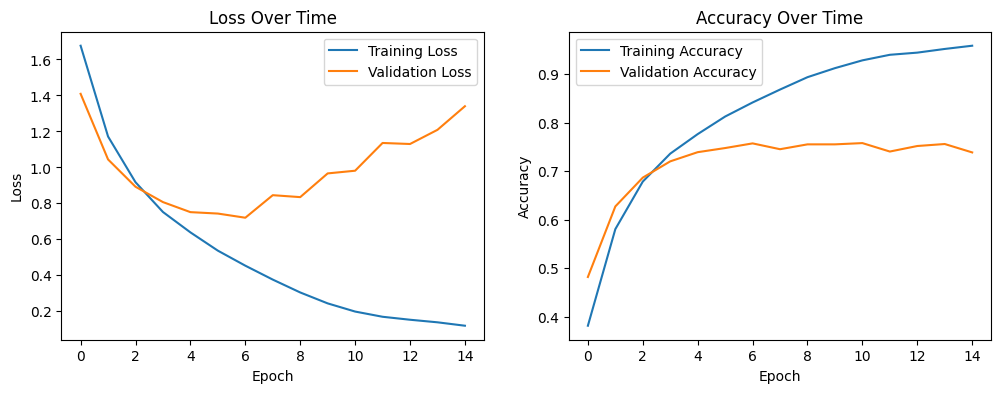

In [47]:
# Plot training history
generate_plot(result)

In [48]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer.h5')
test_loss_CIFAR, test_acc_CIFAR = model.evaluate(test_ds_CIFAR)
print(f"Test Accuracy: {test_acc_CIFAR * 100:.2f}%")

157/157 [==============================] - 1s 4ms/step - loss: 0.7414 - accuracy: 0.7498
Test Accuracy: 74.98%


tf.Tensor(7, shape=(), dtype=int32)
tf.Tensor(0, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(9, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)
(5, 32, 32, 3)
(5, 1)


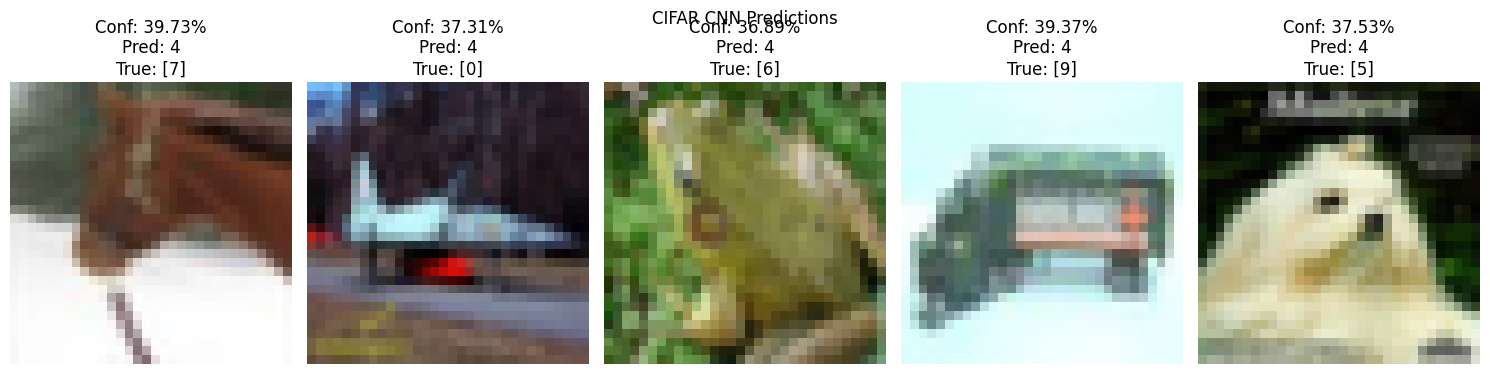

In [ ]:
num_samples = 5
X_vis, y_true = [], []

for img, lbl in test_ds_CIFAR.unbatch().take(num_samples):
    X_vis.append(img)
    y_true.append([lbl])

X_vis = tf.stack(X_vis)
X_vis_norm = tf.cast(X_vis, tf.float32) / 255.0
y_true = tf.stack(y_true)
print(X_vis.shape)
print(y_true.shape)

# Now plot
plot_predictions(
    model,
    X_vis_norm,
    X_vis.numpy(),
    y_true,
    img_shape=(32,32,3),
    cmap=None,
    title="CIFAR CNN Predictions"
)


<a id="3"></a>
## **3. Penerapan Transfer Learning: Penjelasan dan Studi Kasus**
---

<a id=31></a>
### **3.1 Konsep Transfer Learning**

Salah satu metode dalam melakukan tuning model AI yaitu menggunakan transfer learning. Cara kerjanya adalah mentransferkan ilmu (weight) dari dataset yang lebih besar ke modelnya, sehingga hasil prediksi pada dataset yang dituju bisa jauh lebih baik lagi.

<a id=32></a>
### **3.2 Studi Kasus**
Berikut adalah studi kasusnya menggunakan dataset CIFAR10 dengan pretrained weights dari Tiny-Imagenet:

#### Prepare Data

Training dataset has 50000 examples
Validation dataset has 10000 examples


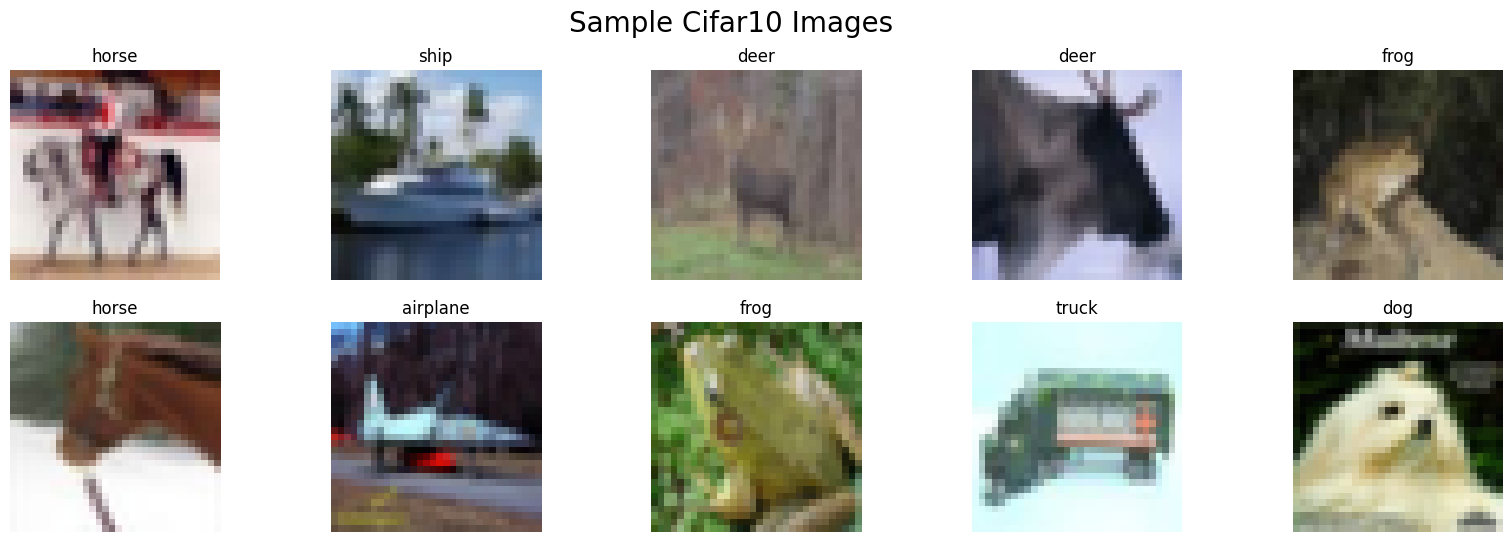

In [ ]:
# Load Cifar10 dataset
(train_ds, val_ds), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

CIFAR_CLASS = info.features["label"].names
print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['test'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        axes[i][j].imshow(data[j][0], cmap='gray')
        axes[i][j].set_title(CIFAR_CLASS[data[j][1].numpy()])
        axes[i][j].axis('off')

plt.suptitle("Sample Cifar10 Images", fontsize=20)
plt.show()

In [ ]:
from functools import partial

def get_transform(image, label, img_size=224):
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

IMG_SIZE = 32
BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


#### Finetune Model

In [ ]:
# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:], name="input_layer"),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),
    layers.Dropout(0.3, name="drop1"),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),
    layers.Dropout(0.3, name="drop2"),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv3"),
    layers.MaxPooling2D((2, 2), name="pool3"),
    layers.Dropout(0.3, name="drop3"),
    
    layers.GlobalAveragePooling2D(name="gap"),

    # Head
    Dense(128, activation='relu', name="fc1"),
    Dense(10, activation='softmax', name="output_layer")
], name="fine_cnn_object_classifier")

# Load pretrained weights and freeze body layers
model.load_weights(
    f"{CKPT_PATH}/cnn_object_recognizer_timagenet.keras", 
    by_name=True, 
    skip_mismatch=True)

initial_weights = model.get_weights()
model.summary()

Model: "fine_cnn_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 32, 32, 32)        896       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 drop1 (Dropout)             (None, 16, 16, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 drop2 (Dropout)             (None, 8, 8, 64)          0         
                                                                 
 conv3 (Conv2D)              (None, 8, 8

In [ ]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/fine_cnn_object_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=150, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/150


2026-02-15 18:34:57.225288: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infine_cnn_object_classifier/drop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


97/98 [============================>.] - ETA: 0s - loss: 1.6154 - accuracy: 0.4145
Epoch 1: val_loss improved from inf to 1.25739, saving model to /app/checkpoints/fine_cnn_object_recognizer.keras
98/98 [==============================] - 6s 28ms/step - loss: 1.6130 - accuracy: 0.4156 - val_loss: 1.2574 - val_accuracy: 0.5450
Epoch 2/150
97/98 [============================>.] - ETA: 0s - loss: 1.1846 - accuracy: 0.5754
Epoch 2: val_loss improved from 1.25739 to 1.04768, saving model to /app/checkpoints/fine_cnn_object_recognizer.keras
98/98 [==============================] - 2s 20ms/step - loss: 1.1843 - accuracy: 0.5755 - val_loss: 1.0477 - val_accuracy: 0.6275
Epoch 3/150
97/98 [============================>.] - ETA: 0s - loss: 1.0880 - accuracy: 0.6097
Epoch 3: val_loss improved from 1.04768 to 1.00832, saving model to /app/checkpoints/fine_cnn_object_recognizer.keras
98/98 [==============================] - 2s 20ms/step - loss: 1.0875 - accuracy: 0.6100 - val_loss: 1.0083 - val_accu

20/20 [==============================] - 0s 7ms/step - loss: 0.5660 - accuracy: 0.8027
Test Accuracy: 80.27%


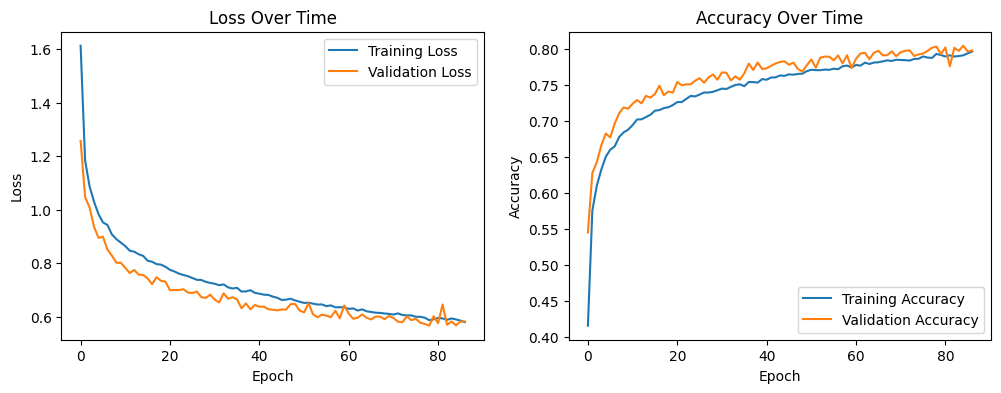

In [ ]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/fine_cnn_object_recognizer.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 85ms/step


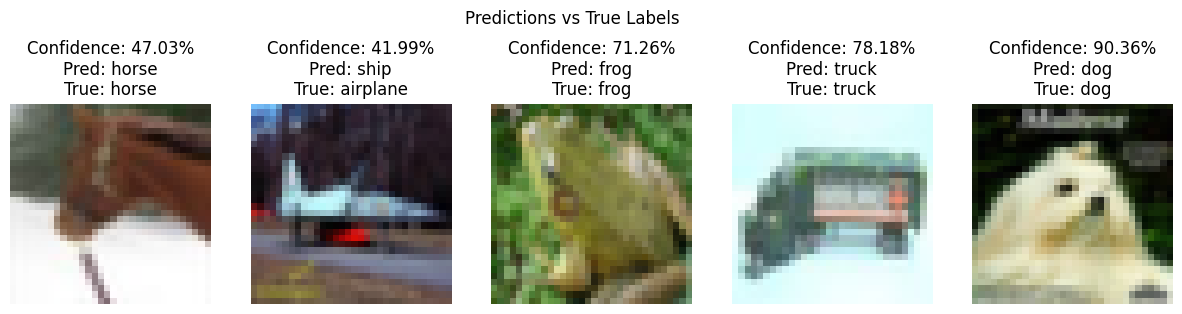

In [ ]:
X_sample, y_sample = next(
    val_ds_proc.unbatch().batch(5).as_numpy_iterator()
)

# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/fine_cnn_object_recognizer.keras')
scores = model.predict(X_sample)
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_sample[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {CIFAR_CLASS[predictions[i]]}\nTrue: {CIFAR_CLASS[y_sample[i]]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()

#### EfficientNet

In [ ]:
# Load Cifar10 dataset
(train_ds, val_ds), info = tfds.load(
    "cifar10",
    split=["train", "test"],
    as_supervised=True,
    with_info=True,
    data_dir="/app/datasets/tfds",
)

CIFAR_CLASS = info.features["label"].names
print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['test'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        axes[i][j].imshow(data[j][0], cmap='gray')
        axes[i][j].set_title(CIFAR_CLASS[data[j][1].numpy()])
        axes[i][j].axis('off')

plt.suptitle("Sample Cifar10 Images", fontsize=20)
plt.show()

In [ ]:
from functools import partial

def get_transform(image, label, img_size=224):
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.efficientnet.preprocess_input(image)
    return image, label

IMG_SIZE = 32
BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(partial(get_transform, img_size=IMG_SIZE), 
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


In [ ]:
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base.trainable = False

# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:], name="input_layer"),
    
    base,

    layers.GlobalAveragePooling2D(name="gap"),
    
    # Head
    # Dense(128, activation='relu', name="fc1"),
    Dense(10, activation='softmax', name="output_layer")
], name="efficientnet_object_classifier")

initial_weights = model.get_weights()
model.summary()

Model: "efficientnet_object_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b0 (Function  (None, 1, 1, 1280)       5919312   
 al)                                                             
                                                                 
 gap (GlobalAveragePooling2D  (None, 1280)             0         
 )                                                               
                                                                 
 output_layer (Dense)        (None, 10)                12810     
                                                                 
Total params: 5,932,122
Trainable params: 12,810
Non-trainable params: 5,919,312
_________________________________________________________________


In [ ]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/efficientnet_object_recognizer.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=150, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/150
97/98 [============================>.] - ETA: 0s - loss: 1.8753 - accuracy: 0.3992
Epoch 1: val_loss improved from inf to 1.57018, saving model to /app/checkpoints/efficientnet_object_recognizer.keras
98/98 [==============================] - 12s 68ms/step - loss: 1.8737 - accuracy: 0.3997 - val_loss: 1.5702 - val_accuracy: 0.4941
Epoch 2/150
97/98 [============================>.] - ETA: 0s - loss: 1.4919 - accuracy: 0.5182
Epoch 2: val_loss improved from 1.57018 to 1.38188, saving model to /app/checkpoints/efficientnet_object_recognizer.keras
98/98 [==============================] - 5s 46ms/step - loss: 1.4911 - accuracy: 0.5185 - val_loss: 1.3819 - val_accuracy: 0.5409
Epoch 3/150
97/98 [============================>.] - ETA: 0s - loss: 1.3668 - accuracy: 0.5490
Epoch 3: val_loss improved from 1.38188 to 1.29851, saving model to /app/checkpoints/efficientnet_object_recognizer.keras
98/98 [==============================] - 4s 45ms/step - loss: 1.3665 - accuracy: 0.5490 - va

20/20 [==============================] - 1s 33ms/step - loss: 1.0115 - accuracy: 0.6504
Test Accuracy: 65.04%


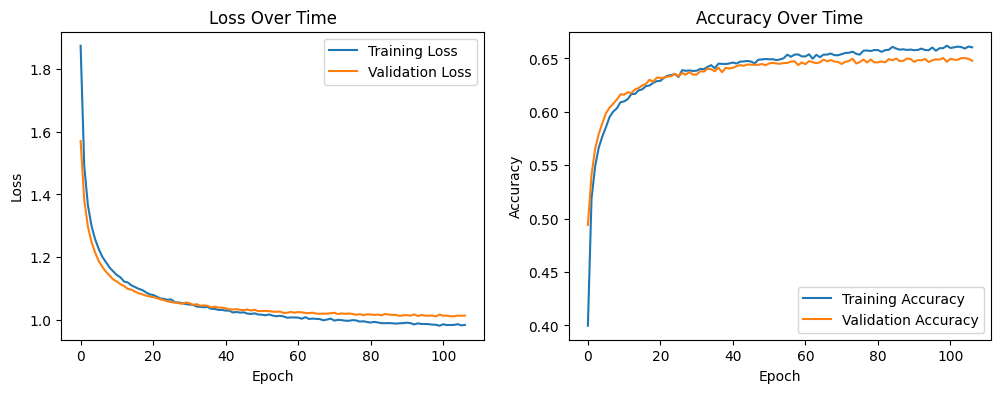

In [ ]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/efficientnet_object_recognizer.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

#### Get Pretrained Weight (Tiny ImageNet)

In [ ]:
# !pip install git+https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git

  Cloning https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git to /tmp/pip-req-build-8ehyxqrs
  Running command git clone --filter=blob:none --quiet https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git /tmp/pip-req-build-8ehyxqrs
  Resolved https://git.ece.iastate.edu/teaching/cpre487_587/tiny-imagenet-tfds.git to commit 425498e42956f129a388b17fbb646c1a5795f03b
  Preparing metadata (setup.py) ... done
  Created wheel for tiny-imagenet-tfds: filename=tiny_imagenet_tfds-0.2.0-py3-none-any.whl size=8231 sha256=89ed533fe67b2ad68a38cc60d6e3ce2707b0374f1e5cb2fb7a9681ff241084f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-7gp25sqa/wheels/f6/df/63/370d7c776a921f7f70c21ae05e8ae26e644df82488d38dbd21
Successfully built tiny-imagenet-tfds


Training dataset has 100000 examples
Validation dataset has 10000 examples


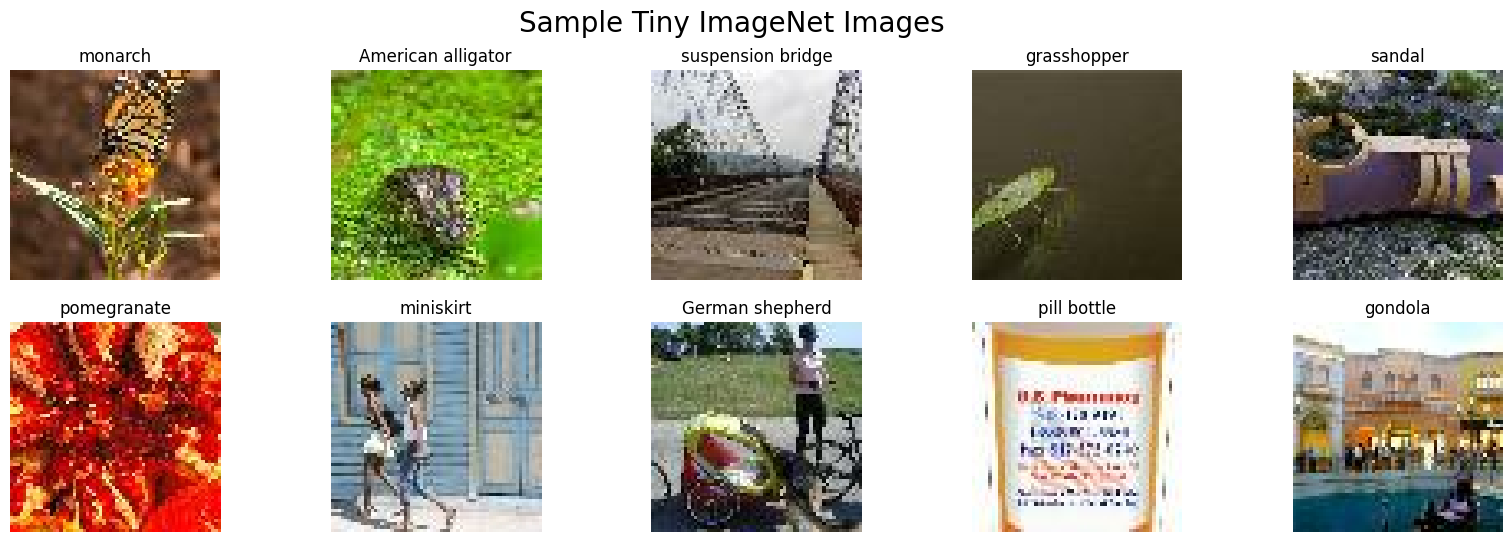

In [ ]:
from tiny_imagenet import TinyImagenetDataset

tiny_imagenet_builder = TinyImagenetDataset()
tiny_imagenet_builder.download_and_prepare()

# Load Tiny ImageNet dataset
(train_ds, val_ds), info = tiny_imagenet_builder.as_dataset(
    split=["train", "validation"],
    # as_supervised=True,
), tiny_imagenet_builder.info

print(f"Training dataset has {info.splits['train'].num_examples} examples")
print(f"Validation dataset has {info.splits['validation'].num_examples} examples")

# Display some sample images
fig, axes = plt.subplots(2, 5, figsize=(20, 6))
for i, data in enumerate([
    list(train_ds.take(5)), list(val_ds.take(5)),
]):
    for j in range(5):
        label = data[j]["metadata"]["label_name"].numpy().decode('utf-8')
        axes[i][j].imshow(data[j]["image"], cmap='gray')
        axes[i][j].set_title(label.split(",")[0])
        axes[i][j].axis('off')

plt.suptitle("Sample Tiny ImageNet Images", fontsize=20)
plt.show()

In [ ]:
from functools import partial

def get_transform(data, img_size=224):
    image = tf.image.resize(data["image"], (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    label = data["label"]
    return image, label

IMG_SIZE = 32
BATCH_SIZE = 512
DATA_LEN = info.splits["train"].num_examples

# Preprocess data
train_ds_proc = (
    train_ds
    .map(partial(get_transform,img_size=IMG_SIZE),
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(DATA_LEN, seed=SEED)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds_proc = (
    val_ds
    .map(partial(get_transform,img_size=IMG_SIZE),
         num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

for data in [train_ds_proc, val_ds_proc]:
    spec = data.element_spec
    print(f"Images of training dataset have shape: {spec[0].shape}, dtype: {spec[0].dtype.name}")
    print(f"Labels of training dataset have shape: {spec[1].shape}, dtype: {spec[1].dtype.name}")

# None in the first index means batch size

Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64
Images of training dataset have shape: (None, 32, 32, 3), dtype: float32
Labels of training dataset have shape: (None,), dtype: int64


In [ ]:
# Create model
model = Sequential([
    layers.Input(shape=train_ds_proc.element_spec[0].shape[1:], name="input_layer"),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same', name="conv1"),
    layers.MaxPooling2D((2, 2), name="pool1"),
    layers.Dropout(0.3, name="drop1"),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same', name="conv2"),
    layers.MaxPooling2D((2, 2), name="pool2"),
    layers.Dropout(0.3, name="drop2"),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same', name="conv3"),
    layers.MaxPooling2D((2, 2), name="pool3"),
    layers.Dropout(0.3, name="drop3"),

    layers.GlobalAveragePooling2D(name="gap"),
    
    # Head
    layers.Dense(128, activation='relu', name="fc1"), 
    # layers.Dropout(0.3, name="drop_fc"),   
    layers.Dense(200, activation='softmax', name="output_layer")
], name="cnn_object_classifier_timagenet")

initial_weights = model.get_weights()
model.summary()

Model: "cnn_object_classifier_timagenet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1 (Conv2D)              (None, 32, 32, 32)        896       
                                                                 
 pool1 (MaxPooling2D)        (None, 16, 16, 32)        0         
                                                                 
 drop1 (Dropout)             (None, 16, 16, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 16, 16, 64)        18496     
                                                                 
 pool2 (MaxPooling2D)        (None, 8, 8, 64)          0         
                                                                 
 drop2 (Dropout)             (None, 8, 8, 64)          0         
                                                                 
 conv3 (Conv2D)              (None,

In [ ]:
# Reset weights
model.set_weights(initial_weights)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=1e-3, 
        weight_decay=1e-4
    ), 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, verbose=1, mode='min')
mcp_save = ModelCheckpoint(f'{CKPT_PATH}/cnn_object_recognizer_timagenet.keras', save_best_only=True, verbose=1, monitor='val_loss')

# Train model with history tracking
result = model.fit(
    train_ds_proc,
    epochs=150, 
    validation_data=val_ds_proc, 
    callbacks=[early_stopping, mcp_save],
)

Epoch 1/150


2026-02-15 18:06:29.936273: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:1014] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape incnn_object_classifier_timagenet/drop1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


193/196 [============================>.] - ETA: 0s - loss: 5.1516 - accuracy: 0.0129
Epoch 1: val_loss improved from inf to 4.94006, saving model to /app/checkpoints/cnn_object_recognizer_timagenet3.keras
196/196 [==============================] - 6s 19ms/step - loss: 5.1496 - accuracy: 0.0130 - val_loss: 4.9401 - val_accuracy: 0.0285
Epoch 2/150
193/196 [============================>.] - ETA: 0s - loss: 4.8595 - accuracy: 0.0346
Epoch 2: val_loss improved from 4.94006 to 4.71191, saving model to /app/checkpoints/cnn_object_recognizer_timagenet3.keras
196/196 [==============================] - 4s 19ms/step - loss: 4.8588 - accuracy: 0.0347 - val_loss: 4.7119 - val_accuracy: 0.0486
Epoch 3/150
193/196 [============================>.] - ETA: 0s - loss: 4.6793 - accuracy: 0.0502
Epoch 3: val_loss improved from 4.71191 to 4.58326, saving model to /app/checkpoints/cnn_object_recognizer_timagenet3.keras
196/196 [==============================] - 4s 19ms/step - loss: 4.6788 - accuracy: 0.0503

20/20 [==============================] - 0s 7ms/step - loss: 3.0476 - accuracy: 0.3015
Test Accuracy: 30.15%


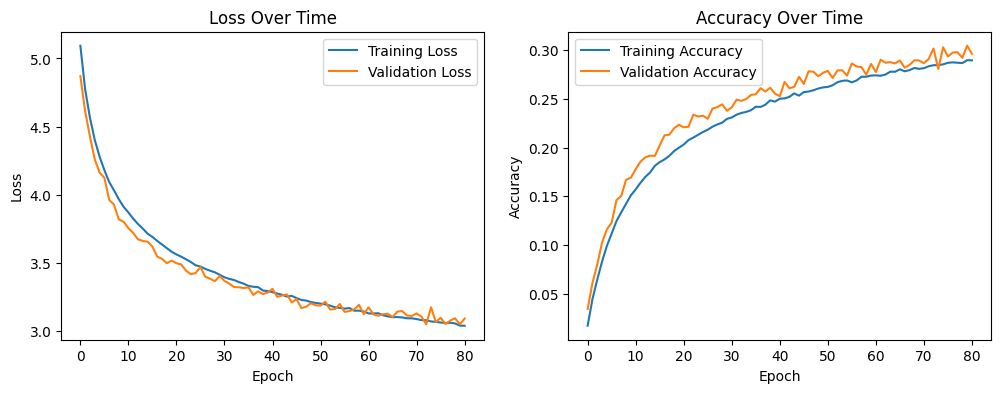

In [ ]:
# Evaluate model
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer_timagenet.keras')
loss, accuracy = model.evaluate(val_ds_proc)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Plot training history
generate_plot(result)

1/1 [==============================] - 0s 52ms/step


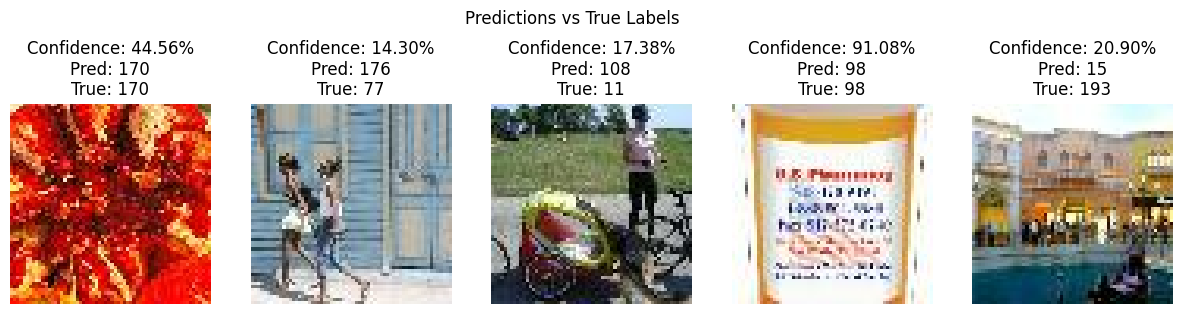

In [ ]:
X_sample, y_sample = next(iter(val_ds_proc.take(1)))

# Predict on test set and visualize some results
model.load_weights(f'{CKPT_PATH}/cnn_object_recognizer_timagenet.keras')
scores = model.predict(X_sample[:5])
predictions = np.argmax(scores, axis=1) # Get predicted class from the max confidence score
y_true = y_sample[:5]

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i in range(5):
    axes[i].imshow(X_sample[i], cmap='gray')
    axes[i].set_title(f"Confidence: {scores[i][predictions[i]]*100:.2f}%\nPred: {predictions[i]}\nTrue: {y_true[i]}")
    axes[i].axis('off')
plt.suptitle("Predictions vs True Labels")
plt.show()